# BigGAN + MidJourney: Cat 4 Classes, CLIP Only + XGBoost / MLP

Notebook ini adalah pasangan dari notebook `09`, tetapi sekarang feature set yang dipakai **hanya CLIP image embedding**, tanpa FFT.

Setup tetap sama:
1. generator: `BigGAN` + `MidJourney`
2. kelas: **4 class kucing yang sama**
3. task: biner `AI vs nature`
4. model: `XGBoost` dan `MLP`

Tujuannya sederhana: membandingkan tiga skenario secara langsung:
1. `FFT only`
2. `FFT + CLIP`
3. `CLIP only`



In [1]:
from pathlib import Path
import hashlib
import json
import re
from collections import Counter

import pandas as pd
import numpy as np
import torch
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from transformers import CLIPModel, CLIPProcessor
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..")
MULTICLASS_ROOT = PROJECT_ROOT / "data" / "raw" / "genimage_multiclass_balanced"
DATA_ROOT = MULTICLASS_ROOT / "genimage"
DATA_ROOTS = {
    "BigGAN": DATA_ROOT / "BigGAN" / "train",
    "MidJourney": DATA_ROOT / "MidJourney" / "train",
}
MANIFEST_SOURCE = MULTICLASS_ROOT / "genimage_multiclass_manifest.csv"
CLASS_TABLE_SOURCE = MULTICLASS_ROOT / "genimage_multiclass_classes.csv"
IMAGENET_MAP = PROJECT_ROOT / "data" / "imagenet_class_index.json"
MANIFEST_OUT = PROJECT_ROOT / "data" / "genimage_manifest_biggan_midjourney_multiclass_train.csv"
CLIP_OUT = PROJECT_ROOT / "artifacts" / "features_clip_biggan_midjourney_multiclass_train.csv"
VECTOR_OUT = PROJECT_ROOT / "artifacts" / "feature_vector_biggan_midjourney_multiclass_clip_only.csv"
METRICS_OUT = PROJECT_ROOT / "artifacts" / "results_classification_biggan_midjourney_multiclass_clip_only.csv"
PRED_OUT = PROJECT_ROOT / "artifacts" / "predictions_classification_biggan_midjourney_multiclass_clip_only.csv"
CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
CLIP_OUT_DIM = 64

print("Data root:", DATA_ROOT.resolve())
print("Manifest source:", MANIFEST_SOURCE.resolve())
print("CLIP model:", CLIP_MODEL_NAME)


/home/nanda/miniconda3/envs/ai/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data root: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/data/raw/genimage_multiclass_balanced/genimage
Manifest source: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/data/raw/genimage_multiclass_balanced/genimage_multiclass_manifest.csv
CLIP model: openai/clip-vit-base-patch32


## 1. Audit data per generator

In [2]:
manifest_source = pd.read_csv(MANIFEST_SOURCE)
class_table = pd.read_csv(CLASS_TABLE_SOURCE)

manifest_source["path_exists"] = manifest_source["path"].map(lambda p: Path(p).is_file())
print("Manifest source:", MANIFEST_SOURCE.resolve())
print("Class table:", CLASS_TABLE_SOURCE.resolve())
print("Manifest shape:", manifest_source.shape)
print("Jumlah kelas:", manifest_source["imagenet_id"].nunique())
print("Semua path ada:", bool(manifest_source["path_exists"].all()))

display(class_table.head(10))
display(
    manifest_source
    .groupby(["generator", "class_name"])
    .size()
    .rename("count")
    .reset_index()
)
display(
    manifest_source
    .groupby(["generator", "class_name", "imagenet_id", "wordnet_id", "content_label"])
    .size()
    .rename("count")
    .reset_index()
    .describe(include="all")
)


Manifest source: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/data/raw/genimage_multiclass_balanced/genimage_multiclass_manifest.csv
Class table: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/data/raw/genimage_multiclass_balanced/genimage_multiclass_classes.csv
Manifest shape: (8000, 16)
Jumlah kelas: 40
Semua path ada: True


,class_id,class_id_str,wnid,label
0,0,0,n01440764,tench
1,1,1,n01443537,goldfish
2,2,2,n01484850,great_white_shark
3,3,3,n01491361,tiger_shark
4,4,4,n01494475,hammerhead
5,5,5,n01496331,electric_ray
6,6,6,n01498041,stingray
7,7,7,n01514668,cock
8,8,8,n01514859,hen
9,9,9,n01518878,ostrich


,generator,class_name,count
0,BigGAN,ai,2000
1,BigGAN,nature,2000
2,MidJourney,ai,2000
3,MidJourney,nature,2000


,generator,class_name,imagenet_id,wordnet_id,content_label,count
count,160,160,160.000000,160,160,160.0
unique,2,2,NaN,40,40,NaN
top,BigGAN,ai,NaN,n01440764,tench,NaN
freq,80,80,NaN,4,4,NaN
mean,NaN,NaN,112.925000,NaN,NaN,50.0
std,NaN,NaN,131.508019,NaN,NaN,0.0
min,NaN,NaN,0.000000,NaN,NaN,50.0
25%,NaN,NaN,9.750000,NaN,NaN,50.0
50%,NaN,NaN,59.500000,NaN,NaN,50.0
75%,NaN,NaN,207.250000,NaN,NaN,50.0


## 2. Bangun manifest gabungan untuk 4 class kucing yang sama


In [3]:
manifest = pd.read_csv(MANIFEST_SOURCE).copy()
manifest["subset_name"] = "biggan_midjourney_multiclass_train"
manifest["split"] = "train"
manifest["path"] = manifest["path"].map(lambda p: str(Path(p).resolve()))

missing_paths = manifest.loc[~manifest["path"].map(lambda p: Path(p).is_file()), "path"].head()
if len(missing_paths):
    raise FileNotFoundError(
        "Ada path manifest yang tidak ditemukan, contoh: "
        + str(missing_paths.tolist())
    )

manifest.to_csv(MANIFEST_OUT, index=False)
print("Saved manifest:", MANIFEST_OUT.resolve())
print("Manifest shape:", manifest.shape)
display(manifest.head())
display(manifest.groupby(["generator", "y_ai"]).size().rename("count").reset_index())
display(
    manifest
    .groupby(["generator", "class_name", "content_label"])
    .size()
    .rename("count")
    .reset_index()
    .head(20)
)


Saved manifest: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/data/genimage_manifest_biggan_midjourney_multiclass_train.csv
Manifest shape: (8000, 15)


,image_id,path,relative_path,archive_path,internal_path,generator,subset_name,split,class_name,content_id,content_label,imagenet_id,wordnet_id,is_real,y_ai
0,BigGAN_ai_000_000000,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00037.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,tench,0,n01440764,False,1
1,BigGAN_ai_000_000001,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00007.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,tench,0,n01440764,False,1
2,BigGAN_ai_000_000002,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00086.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,tench,0,n01440764,False,1
3,BigGAN_ai_000_000003,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00077.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,tench,0,n01440764,False,1
4,BigGAN_ai_000_000004,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00070.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,tench,0,n01440764,False,1


,generator,y_ai,count
0,BigGAN,0,2000
1,BigGAN,1,2000
2,MidJourney,0,2000
3,MidJourney,1,2000


,generator,class_name,content_label,count
0,BigGAN,ai,Chesapeake_Bay_retriever,50
1,BigGAN,ai,Chihuahua,50
2,BigGAN,ai,Egyptian_cat,50
3,BigGAN,ai,German_short-haired_pointer,50
4,BigGAN,ai,Labrador_retriever,50
5,BigGAN,ai,Persian_cat,50
6,BigGAN,ai,Siamese_cat,50
7,BigGAN,ai,ambulance,50
8,BigGAN,ai,beach_wagon,50
9,BigGAN,ai,black_swan,50


## 3. Ekstraksi CLIP image embedding

In [4]:
if CLIP_OUT.exists():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Loaded existing CLIP features later; skip CLIP model initialization.")
else:
    device = "cuda" if torch.cuda.is_available() else "cpu"
    processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME, local_files_only=True)
    model = CLIPModel.from_pretrained(CLIP_MODEL_NAME, local_files_only=True).to(device)
    model.eval()
    print("device:", device)
    print("projection_dim:", model.config.projection_dim)


Loaded existing CLIP features later; skip CLIP model initialization.


In [5]:
if CLIP_OUT.exists():
    clip_df = pd.read_csv(CLIP_OUT)
    print("Loaded CLIP features:", CLIP_OUT.resolve())
else:
    def extract_clip_vector(path: str, out_dim: int = 64):
        image = Image.open(path).convert("RGB")
        inputs = processor(images=image, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            out = model.get_image_features(**inputs)
            if hasattr(out, "pooler_output"):
                feats = out.pooler_output
            elif torch.is_tensor(out):
                feats = out
            else:
                raise TypeError(f"Unexpected CLIP output type: {type(out)}")
            feats = feats / feats.norm(p=2, dim=-1, keepdim=True)
        vec = feats.squeeze(0).detach().cpu().numpy().astype(np.float32)
        if out_dim < vec.shape[0]:
            vec = vec[:out_dim]
        elif out_dim > vec.shape[0]:
            vec = np.concatenate([vec, np.zeros(out_dim - vec.shape[0], dtype=np.float32)])
        return vec

    clip_rows = []
    for idx, row in enumerate(manifest.itertuples(index=False), start=1):
        vec = extract_clip_vector(row.path, out_dim=CLIP_OUT_DIM)
        item = {"image_id": row.image_id}
        for i, v in enumerate(vec):
            item[f"clip_feat_{i:03d}"] = float(v)
        clip_rows.append(item)
        if idx % 100 == 0:
            print(f"Processed CLIP {idx}/{len(manifest)} images")

    clip_df = pd.DataFrame(clip_rows)
    clip_df.to_csv(CLIP_OUT, index=False)
    print("Saved CLIP features:", CLIP_OUT.resolve())

display(clip_df.head())


Loaded CLIP features: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/features_clip_biggan_midjourney_multiclass_train.csv


,image_id,clip_feat_000,clip_feat_001,clip_feat_002,clip_feat_003,clip_feat_004,clip_feat_005,clip_feat_006,clip_feat_007,clip_feat_008,...,clip_feat_054,clip_feat_055,clip_feat_056,clip_feat_057,clip_feat_058,clip_feat_059,clip_feat_060,clip_feat_061,clip_feat_062,clip_feat_063
0,BigGAN_ai_000_000000,0.023383,0.033415,0.000783,0.000693,0.001556,0.028215,-0.023073,0.015947,0.060079,...,0.033839,0.013861,0.008991,0.049043,-0.045764,0.022915,0.107769,-0.025100,-0.033920,-0.008896
1,BigGAN_ai_000_000001,-0.005320,0.025451,-0.001197,0.040806,0.008424,0.023826,-0.031863,-0.036118,0.093952,...,0.003529,-0.015651,0.038348,0.043967,-0.016589,0.021125,0.092690,-0.019105,-0.017591,0.000008
2,BigGAN_ai_000_000002,0.018574,0.012184,0.006055,0.021351,-0.015919,-0.043677,-0.025114,0.006281,0.049114,...,0.043169,-0.033627,0.021230,0.031247,-0.043649,-0.004992,0.102849,-0.007372,-0.003672,0.005130
3,BigGAN_ai_000_000003,0.024487,0.034794,-0.013841,-0.000896,0.002640,0.002252,-0.023318,0.002641,0.074824,...,0.037015,-0.001909,-0.009840,0.044110,-0.047930,0.006833,0.097258,-0.017063,-0.046253,0.008082
4,BigGAN_ai_000_000004,-0.003053,0.005584,0.027832,0.041834,0.018493,-0.015387,-0.031849,-0.006884,0.080148,...,0.007375,-0.012183,0.069066,0.075082,-0.045463,0.035869,0.091091,-0.002146,-0.025999,0.006019


## 4. Bangun feature vector CLIP only

In [6]:
data = manifest.merge(clip_df, on="image_id", how="inner")
meta_cols = ["image_id", "path", "relative_path", "generator", "subset_name", "split", "class_name", "content_id", "content_label", "is_real", "y_ai"]
feature_cols = [
    c for c in data.columns
    if c.startswith(("fft_", "clip_feat_")) or c in ["piqe", "brisque", "niqe"]
]

data.to_csv(VECTOR_OUT, index=False)
print("Merged shape:", data.shape)
print("Feature dims:", len(feature_cols))
print("Saved vector:", VECTOR_OUT.resolve())
display(data.head())

Merged shape: (8000, 79)
Feature dims: 64
Saved vector: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/feature_vector_biggan_midjourney_multiclass_clip_only.csv


,image_id,path,relative_path,archive_path,internal_path,generator,subset_name,split,class_name,content_id,...,clip_feat_054,clip_feat_055,clip_feat_056,clip_feat_057,clip_feat_058,clip_feat_059,clip_feat_060,clip_feat_061,clip_feat_062,clip_feat_063
0,BigGAN_ai_000_000000,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00037.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,...,0.033839,0.013861,0.008991,0.049043,-0.045764,0.022915,0.107769,-0.025100,-0.033920,-0.008896
1,BigGAN_ai_000_000001,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00007.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,...,0.003529,-0.015651,0.038348,0.043967,-0.016589,0.021125,0.092690,-0.019105,-0.017591,0.000008
2,BigGAN_ai_000_000002,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00086.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,...,0.043169,-0.033627,0.021230,0.031247,-0.043649,-0.004992,0.102849,-0.007372,-0.003672,0.005130
3,BigGAN_ai_000_000003,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00077.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,...,0.037015,-0.001909,-0.009840,0.044110,-0.047930,0.006833,0.097258,-0.017063,-0.046253,0.008082
4,BigGAN_ai_000_000004,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00070.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,...,0.007375,-0.012183,0.069066,0.075082,-0.045463,0.035869,0.091091,-0.002146,-0.025999,0.006019


## 5. Split 80:20 dengan stratifikasi gabungan

In [7]:
X = data[feature_cols].to_numpy(dtype=np.float32)
y = data["y_ai"].to_numpy(dtype=np.int64)
stratify_key = data["generator"].astype(str) + "|" + data["y_ai"].astype(str) + "|" + data["content_label"].astype(str)

X_train, X_eval, y_train, y_eval, train_idx, eval_idx = train_test_split(
    X, y, data.index.to_numpy(), test_size=0.2, random_state=42, stratify=stratify_key
)

print("Train:", X_train.shape, y_train.shape)
print("Eval:", X_eval.shape, y_eval.shape)

Train: (6400, 64) (6400,)
Eval: (1600, 64) (1600,)


## 6. Train baseline dengan CLIP only

In [8]:
models = {
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42,
    ),
    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(hidden_layer_sizes=(128, 64), activation="relu", max_iter=500, random_state=42)),
    ]),
}

results = []
pred_store = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    score_ai = model.predict_proba(X_eval)[:, 1]
    pred_ai = (score_ai >= 0.5).astype(np.int64)
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_eval, pred_ai),
        "f1": f1_score(y_eval, pred_ai),
        "auroc": roc_auc_score(y_eval, score_ai),
    })
    pred_store[name] = {"score_ai": score_ai, "pred_ai": pred_ai}

results_df = pd.DataFrame(results).sort_values(by=["auroc", "f1", "accuracy"], ascending=False).reset_index(drop=True)
display(results_df)

,model,accuracy,f1,auroc
0,MLP,0.939375,0.939714,0.985052
1,XGBoost,0.902500,0.903226,0.967389


## 7. Confusion matrix model terbaik

Best model: MLP

              precision    recall  f1-score   support

      nature       0.94      0.93      0.94       800
          ai       0.93      0.94      0.94       800

    accuracy                           0.94      1600
   macro avg       0.94      0.94      0.94      1600
weighted avg       0.94      0.94      0.94      1600



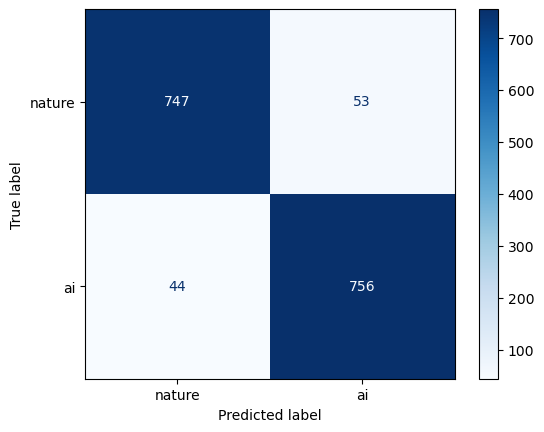

In [9]:
best_model = results_df.iloc[0]["model"]
print("Best model:", best_model)
print()
print(classification_report(y_eval, pred_store[best_model]["pred_ai"], target_names=["nature", "ai"]))
cm = confusion_matrix(y_eval, pred_store[best_model]["pred_ai"])
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["nature", "ai"]).plot(cmap="Blues")
plt.show()

## 8. Simpan hasil

In [10]:
metrics_df = results_df.copy()
metrics_df["feature_set"] = "clip_only"
metrics_df["clip_model"] = CLIP_MODEL_NAME
metrics_df["clip_out_dim"] = CLIP_OUT_DIM
metrics_df["split_protocol"] = "train_holdout_80_20_stratified_generator_label_class"
metrics_df["subset_name"] = "biggan_midjourney_multiclass_train"
metrics_df["n_total"] = len(data)
metrics_df["n_train"] = len(X_train)
metrics_df["n_eval"] = len(X_eval)
metrics_df.to_csv(METRICS_OUT, index=False)

base_eval = data.iloc[eval_idx][["image_id", "path", "generator", "class_name", "content_id", "content_label", "y_ai"]].copy()
pred_parts = []
for name, pred in pred_store.items():
    part = base_eval.copy()
    part["model"] = name
    part["score_ai"] = pred["score_ai"]
    part["pred_ai"] = pred["pred_ai"]
    pred_parts.append(part)

pred_df = pd.concat(pred_parts, ignore_index=True)
pred_df.to_csv(PRED_OUT, index=False)

print("Saved metrics:", METRICS_OUT.resolve())
print("Saved predictions:", PRED_OUT.resolve())
display(metrics_df)
display(pred_df.head())


Saved metrics: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/results_classification_biggan_midjourney_multiclass_clip_only.csv
Saved predictions: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/predictions_classification_biggan_midjourney_multiclass_clip_only.csv


,model,accuracy,f1,auroc,feature_set,clip_model,clip_out_dim,split_protocol,subset_name,n_total,n_train,n_eval
0,MLP,0.939375,0.939714,0.985052,clip_only,openai/clip-vit-base-patch32,64,train_holdout_80_20_stratified_generator_label...,biggan_midjourney_multiclass_train,8000,6400,1600
1,XGBoost,0.902500,0.903226,0.967389,clip_only,openai/clip-vit-base-patch32,64,train_holdout_80_20_stratified_generator_label...,biggan_midjourney_multiclass_train,8000,6400,1600


,image_id,path,generator,class_name,content_id,content_label,y_ai,model,score_ai,pred_ai
0,BigGAN_nature_436_003899,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN,nature,n02814533,beach_wagon,0,XGBoost,0.186452,0
1,MidJourney_ai_107_006446,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,MidJourney,ai,107,jellyfish,1,XGBoost,0.664260,1
2,BigGAN_ai_014_001413,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN,ai,014,indigo_bunting,1,XGBoost,0.964389,1
3,BigGAN_ai_102_002207,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN,ai,102,echidna,1,XGBoost,0.915871,1
4,BigGAN_nature_016_001690,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN,nature,n01560419,bulbul,0,XGBoost,0.056652,0


## 9. Catatan interpretasi
Notebook ini harus dibaca bersama notebook `08` dan `09`:
1. `08` = FFT only
2. `09` = FFT + CLIP
3. `10` = CLIP only

Dengan tiga notebook ini, kita bisa menilai dengan jelas apakah sinyal semantik dari CLIP memang menambah nilai, atau justru fitur spektral sudah dominan pada setup ini.